# Pipeline Dự báo AMZN bằng Keras Vanilla RNN

Notebook này thực thi toàn bộ pipeline Keras/TensorFlow để dự báo sử dụng RNN.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, RNN, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Đặt seed để đảm bảo tính tái lập
tf.random.set_seed(42)
np.random.seed(42)
os.makedirs('../models', exist_ok=True)

## Bước 1: Tiền Xử lý Dữ liệu & Kỹ thuật Chuỗi
- Làm sạch dữ liệu, xử lý thời gian
- Chia tập dữ liệu theo thời gian (70% Train, 15% Val, 15% Test)
- Chia tỷ lệ bằng `MinMaxScaler(-1, 1)` CHỈ TRÊN TẬP HUẤN LUYỆN (Train)
- Tạo chuỗi tensor 3D cửa sổ trượt: `(batch_size, sequence_length, feature_dim)`

In [2]:
df = pd.read_csv('../data/AMZN.csv')
date_col = 'Date' if 'Date' in df.columns else df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)
df.sort_index(inplace=True)

target_col = 'Close' if 'Close' in df.columns else ('Price' if 'Price' in df.columns else df.columns[0])
df[target_col] = df[target_col].ffill().bfill()
data = df[[target_col]].values

# Chia tập dữ liệu
n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

# Khởi tạo và Fit Scaler trên Train
scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# Hàm tạo chuỗi
def create_sequences(data_array, seq_length=30):
    xs, ys = [], []
    for i in range(len(data_array) - seq_length):
        xs.append(data_array[i:(i + seq_length)])
        ys.append(data_array[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 30
X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_val, y_val = create_sequences(val_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)
print(f"Kích thước X_train: {X_train.shape}")

Kích thước X_train: (4648, 30, 1)


## Bước 2: Thiết kế Kiến trúc Mô hình
Xây dựng kiến trúc RNN Keras nhiều-thành-một (Many-to-One).

In [3]:
model = Sequential([
    SimpleRNN(64, return_sequences=False, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    Dense(1)
])
model.summary()

/opt/anaconda3/lib/python3.14/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

## Bước 3: Cấu hình Huấn luyện
Sử dụng bộ tối ưu Adam với `clipnorm=1.0` (Gradient Clipping) để chống bùng nổ đạo hàm.

In [4]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=opt, loss='mse', metrics=['mae'])

## Bước 4: Vòng lặp Huấn luyện & Chẩn đoán (BPTT)

Epoch 1/100


 1/73 ━━━━━━━━━━━━━━━━━━━━ 37s 518ms/step - loss: 0.1114 - mae: 0.2700

21/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0329 - mae: 0.1373   

38/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0230 - mae: 0.1122

46/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0205 - mae: 0.1051

...

Epoch 75/100


 1/73 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - mae: 0.0220

26/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.2181e-04 - mae: 0.0208

51/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.9196e-04 - mae: 0.0215

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6510e-04 - mae: 0.0214 - val_loss: 0.2717 - val_mae: 0.3746 - learning_rate: 1.2500e-04


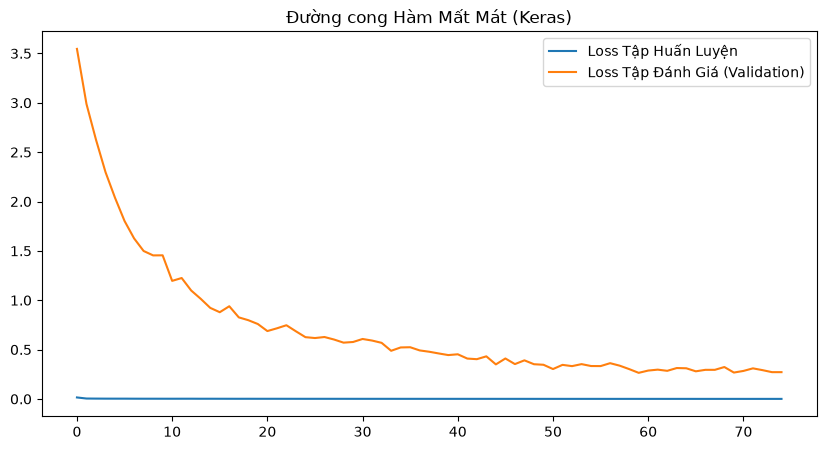

In [5]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stopping, lr_scheduler], verbose=1)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss Tập Huấn Luyện')
plt.plot(history.history['val_loss'], label='Loss Tập Đánh Giá (Validation)')
plt.title('Đường cong Hàm Mất Mát (Keras)')
plt.legend()
plt.show()

## Bước 5: Đánh giá Độc lập & Chẩn đoán trên Tập Kiểm tra
Khôi phục (inverse transform) dự đoán và tính toán RMSE, MAE, MAPE.

 1/31 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


RMSE (Tập Kiểm tra): 57.0424
MAE (Tập Kiểm tra):  51.5550
MAPE (Tập Kiểm tra): 0.3518
Độ chính xác về hướng: 0.4979


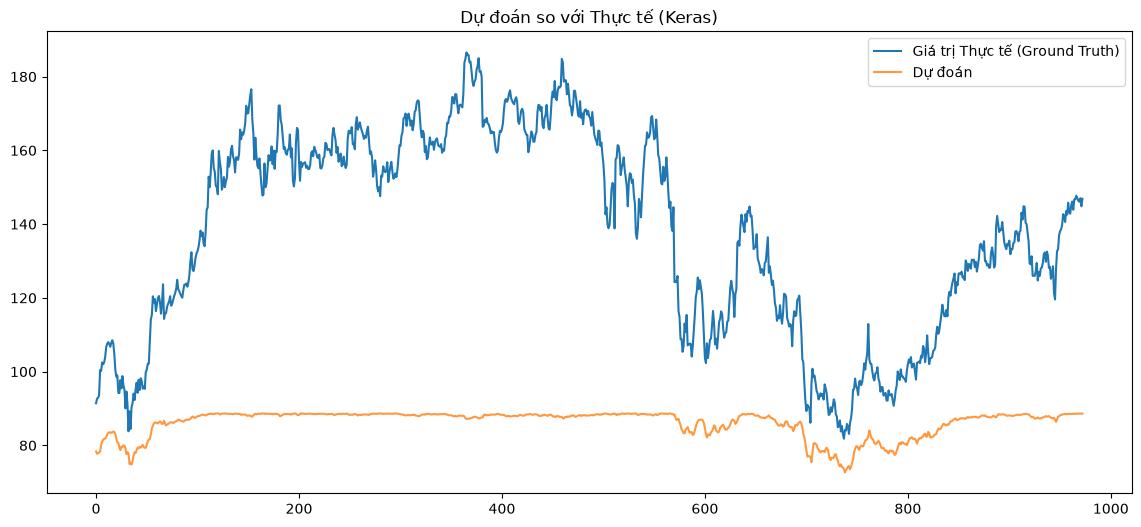

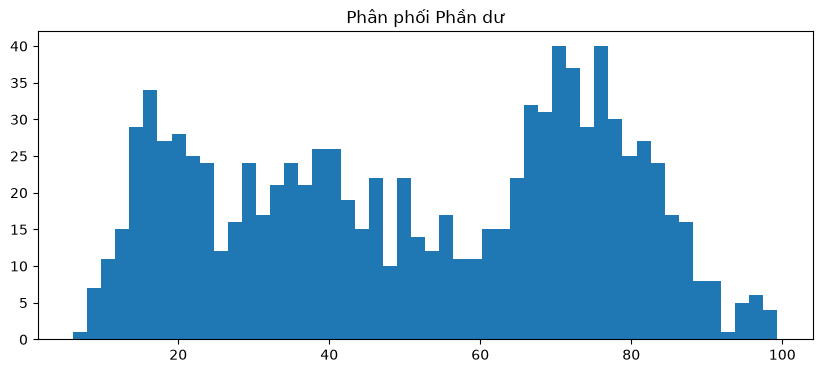

In [6]:
preds = model.predict(X_test)
preds_inv = scaler.inverse_transform(preds)
targets_inv = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(targets_inv, preds_inv))
mae = mean_absolute_error(targets_inv, preds_inv)
mape = mean_absolute_percentage_error(targets_inv, preds_inv)

# Độ chính xác hướng
actual_diff = np.diff(targets_inv.flatten())
pred_diff = np.diff(preds_inv.flatten())
directional_acc = np.mean(np.sign(actual_diff) == np.sign(pred_diff))

print(f"RMSE (Tập Kiểm tra): {rmse:.4f}")
print(f"MAE (Tập Kiểm tra):  {mae:.4f}")
print(f"MAPE (Tập Kiểm tra): {mape:.4f}")
print(f"Độ chính xác về hướng: {directional_acc:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(targets_inv, label='Giá trị Thực tế (Ground Truth)')
plt.plot(preds_inv, label='Dự đoán', alpha=0.8)
plt.title('Dự đoán so với Thực tế (Keras)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(targets_inv - preds_inv, bins=50)
plt.title('Phân phối Phần dư')
plt.show()

## Bước 6: Tuần tự hóa (Serialization) & Kiểm chứng

In [7]:
model.save('../models/keras_rnn_amzn.keras')

bundle = {
    "model_name": "keras_rnn_amzn",
    "framework": "keras",
    "target_column": target_col,
    "seq_length": SEQ_LENGTH,
    "scaler": scaler,
    "metrics": {
        "rmse": float(rmse),
        "mae": float(mae),
        "mape": float(mape),
        "directional_acc": float(directional_acc)
    },
    "model_path": "models/keras_rnn_amzn.keras"
}
with open('../models/keras_rnn_amzn.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f"Đã xuất bundle thành công ra: models/keras_rnn_amzn.pkl")

Đã xuất bundle thành công ra: models/keras_rnn_amzn.pkl
